# AI 854 · Lecture 4 — What does an average hide?

**One case, five questions, after one season of context.** Every step ends with a result that forces the next question.

| Act | Question | What we compute |
|---|---|---|
| 0 | What happened in the season? | results, scores, chases, the three meetings |
| 1 | Do two teams with the same average score the same way? | means, then every raw over |
| 2 | What exactly differs between two distributions? | histogram, ECDF, quantiles, tail rates, effect sizes |
| 3 | How many independent observations do we really have? | matches, clusters, weights |
| 4 | How sure are we? | IID and match-cluster bootstrap |
| 5 | What can we defend? | claim ladder |

**How this notebook is used.** Before each cell, predict what it will show; after it runs, explain the result in your own words. The saved outputs are the study reference.

In [1]:
# Google Colab only: download this lecture's data and helper files, then work inside that folder.
# Running locally? Start Jupyter in the lecture folder and this cell does nothing.
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('requirements.txt'):
    !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/DrFarrukh/teaching.git /content/teaching
    !git -C /content/teaching sparse-checkout set courses/data-analysis-and-visualization/lectures/lecture-04
    os.chdir('/content/teaching/courses/data-analysis-and-visualization/lectures/lecture-04')
    !pip -q install -r requirements.txt
    print('Working folder:', os.getcwd())

## Setup and data contract

- Source: frozen Cricsheet Pakistan Super League archive.
- Observation: one recorded over in one innings.
- Eligible over: exactly six legal balls.
- Death phase: overs 16 to 20.
- Case: 2017 season, Peshawar Zalmi and Quetta Gladiators batting.
- Outcome: total runs in the over, including extras.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA, OUT = Path("data"), Path("outputs")
OUT.mkdir(exist_ok=True)
NAVY, TEAL, ORANGE, RED, GRAY = "#143e59", "#1f6f8b", "#d97706", "#b54747", "#667786"
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlecolor": NAVY})
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

def save(fig, name):
    fig.savefig(OUT / name, dpi=150, bbox_inches="tight", facecolor="white")

RESULTS = {}   # every headline number lands here and is exported by the last cell
P, Q = "Peshawar Zalmi", "Quetta Gladiators"
COLORS = {P: TEAL, Q: ORANGE}

overs = pd.read_csv(DATA / "psl_overs.csv", parse_dates=["match_date"], dtype={"match_id": str})
case = pd.read_csv(DATA / "death_overs_2017_comparison.csv", parse_dates=["match_date"], dtype={"match_id": str})
matches = pd.read_csv(DATA / "psl_matches.csv", parse_dates=["match_date"], dtype={"match_id": str})
p = case.loc[case.batting_team == P, "total_runs"].to_numpy()
q = case.loc[case.batting_team == Q, "total_runs"].to_numpy()
overs.shape, case.shape

((13594, 22), (81, 14))

In [3]:
# Data contract: the checks that must pass before any analysis is trusted.
assert overs[["match_id", "innings", "over_number"]].duplicated().sum() == 0
assert overs.complete_over.eq(overs.legal_balls.eq(6)).all()
assert case.over_number.between(16, 20).all() and (case.match_date.dt.year == 2017).all()

RESULTS.update(
    archive_matches=int(overs.match_id.nunique()), archive_overs=len(overs),
    archive_complete=int(overs.complete_over.sum()),
    n_p=len(p), n_q=len(q), rows=len(case),
)
{k: RESULTS[k] for k in ["archive_matches", "archive_overs", "archive_complete", "n_p", "n_q", "rows"]}

{'archive_matches': 357,
 'archive_overs': 13594,
 'archive_complete': 13336,
 'n_p': 44,
 'n_q': 37,
 'rows': 81}

# Act 0 — The season

Before any statistic, the story. **PSL 2017**, played in the UAE with the final in Lahore. Two of the five teams, Peshawar Zalmi and Quetta Gladiators, meet three times in the last nine days of the season. This act uses only what is in the archive: who played, what they scored, who won, who chased.

**Predict:** in a T20 season, how close do you expect the final scores to be?

In [4]:
s17 = matches[matches.season_year == 2017].sort_values(["match_date", "match_id"]).reset_index(drop=True)
s17["stage"] = np.where(s17.index < 20, "League", "Playoff")
s17.loc[s17.index[-1], "stage"] = "Final"

# The archive has no stage label. Inference: 20 league games = 5 teams x 8 games, then 4 playoff games.
league_games = pd.concat([s17[s17.stage == "League"].team_1, s17[s17.stage == "League"].team_2]).value_counts()
assert len(s17) == 24 and (league_games == 8).all() and len(league_games) == 5
assert s17.iloc[-1].venue.startswith("Gaddafi") and {s17.iloc[-1].team_1, s17.iloc[-1].team_2} == {P, Q}

ABBR = {"Peshawar Zalmi": "PZ", "Quetta Gladiators": "QG", "Islamabad United": "IU",
        "Karachi Kings": "KK", "Lahore Qalandars": "LQ"}
s17["label"] = [f"{d:%d %b}  {ABBR[a]} v {ABBR[b]}" for d, a, b in zip(s17.match_date, s17.team_1, s17.team_2)]

innings_totals = (overs[overs.season_year == 2017].groupby(["match_id", "innings", "batting_team"])
                  .agg(runs=("total_runs", "sum"), wickets=("dismissals", "sum")).reset_index())

def season_log(team):
    rows = []
    for _, r in s17[(s17.team_1 == team) | (s17.team_2 == team)].iterrows():
        t = innings_totals[innings_totals.match_id == r.match_id]
        mine, theirs = t[t.batting_team == team], t[t.batting_team != team]
        opp = r.team_2 if r.team_1 == team else r.team_1
        rows.append({
            "date": r.match_date, "stage": r.stage, "opponent": opp, "venue": r.venue.split()[0],
            "role": "chased" if len(mine) and mine.innings.iloc[0] == 2 else "batted first" if len(mine) else "-",
            "runs": mine.runs.iloc[0] if len(mine) else np.nan,
            "opp_runs": theirs.runs.iloc[0] if len(theirs) else np.nan,
            "result": "No result" if pd.isna(r.winner) else "Won" if r.winner == team else "Lost",
            "dl": r.method == "D/L", "match_id": r.match_id, "label": r.label})
    return pd.DataFrame(rows)

log = {P: season_log(P), Q: season_log(Q)}
record = pd.DataFrame({team: {
    "matches": len(g), "won": (g.result == "Won").sum(), "lost": (g.result == "Lost").sum(),
    "no result": (g.result == "No result").sum(),
    "league W-L": f'{((g.stage == "League") & (g.result == "Won")).sum()}-{((g.stage == "League") & (g.result == "Lost")).sum()}',
    "playoffs W-L": f'{((g.stage != "League") & (g.result == "Won")).sum()}-{((g.stage != "League") & (g.result == "Lost")).sum()}',
} for team, g in log.items()}).T
for key, team in [("p", P), ("q", Q)]:
    g = log[team]
    RESULTS.update({f"season_played_{key}": len(g), f"season_won_{key}": int((g.result == "Won").sum()),
                    f"season_lost_{key}": int((g.result == "Lost").sum()),
                    f"season_nr_{key}": int((g.result == "No result").sum())})
record

,matches,won,lost,no result,league W-L,playoffs W-L
Peshawar Zalmi,11,6,4,1,4-3,2-1
Quetta Gladiators,10,5,4,1,4-3,1-1


Now every match, one row each. The dot on the right is the team's own total; the grey dot is the opponent's. A short line means a close game.

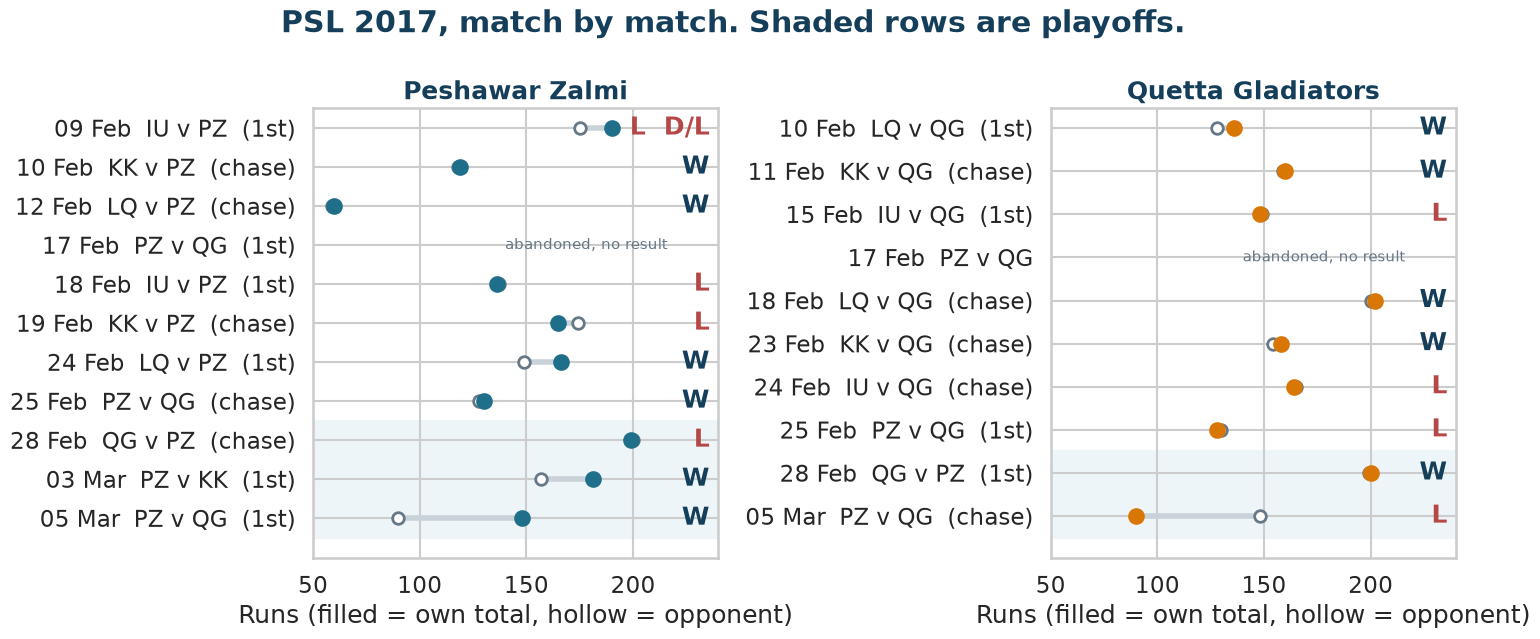

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.6), sharex=True)
for ax, team in zip(axes, [P, Q]):
    g = log[team].reset_index(drop=True)
    for y, r in g.iterrows():
        if np.isnan(r.runs) or np.isnan(r.opp_runs):
            ax.text(140, y, "abandoned, no result", va="center", color=GRAY, fontsize=11)
            continue
        ax.plot([r.opp_runs, r.runs], [y, y], color="#c9d2d9", lw=4, zorder=1)
        ax.scatter(r.opp_runs, y, s=70, color="white", edgecolor=GRAY, lw=2, zorder=2)
        ax.scatter(r.runs, y, s=110, color=COLORS[team], zorder=3)
        tag = {"Won": "W", "Lost": "L"}[r.result] + ("  D/L" if r.dl else "")
        ax.text(236, y, tag, va="center", ha="right", fontweight="bold", color=NAVY if r.result == "Won" else RED)
    ax.set_yticks(range(len(g)), [lab + {"chased": "  (chase)", "batted first": "  (1st)", "-": ""}[role] for lab, role in zip(g.label, g.role)])
    ax.invert_yaxis()
    for y in np.flatnonzero(g.stage.to_numpy() != "League"):
        ax.axhspan(y - .5, y + .5, color="#eef5f8", zorder=0)
    ax.set(title=team, xlabel="Runs (filled = own total, hollow = opponent)", xlim=(50, 240))
fig.suptitle("PSL 2017, match by match. Shaded rows are playoffs.", color=NAVY, fontweight="bold")
fig.tight_layout()
save(fig, "season_results.png")
plt.show()

**Read it.** Most dots sit almost on top of their grey partner. Close games were the rule. Count how many finished within five runs.

In [6]:
def gap_table(team):
    g = log[team]
    g = g[g.runs.notna() & g.opp_runs.notna() & ~g.dl]
    return (g.runs - g.opp_runs).abs()

close = pd.DataFrame({"decided games": [len(gap_table(P)), len(gap_table(Q))],
                      "totals within 5 runs": [(gap_table(P) <= 5).sum(), (gap_table(Q) <= 5).sum()]},
                     index=["Peshawar", "Quetta"])
# Scores quoted on the slides; the build fails if the archive ever disagrees.
def has_score(team, own, opp):
    g = log[team]
    return bool(((g.runs == own) & (g.opp_runs == opp)).any())
assert has_score(P, 60, 59) and has_score(P, 119, 118) and has_score(Q, 160, 159) and has_score(Q, 200, 199)
assert has_score(P, 130, 128) and has_score(P, 199, 200) and has_score(P, 148, 90) and has_score(Q, 90, 148)
RESULTS.update(decided_p=int(close.iloc[0, 0]), decided_q=int(close.iloc[1, 0]),
               close_p=int(close.iloc[0, 1]), close_q=int(close.iloc[1, 1]))
close

,decided games,totals within 5 runs
Peshawar,9,5
Quetta,9,7


## The three meetings

Peshawar and Quetta met four times. One game was abandoned; three were completed, the last of them the final.

In [7]:
h2h = s17[((s17.team_1 == P) & (s17.team_2 == Q)) | ((s17.team_1 == Q) & (s17.team_2 == P))]
rows = []
for _, r in h2h.iterrows():
    t = innings_totals[innings_totals.match_id == r.match_id].sort_values("innings")
    rows.append({"date": f"{r.match_date:%d %b}", "stage": r.stage, "venue": r.venue,
                 "first innings": " ".join(f"{ABBR[a]} {int(b)}" for a, b in zip(t.batting_team[:1], t.runs[:1])),
                 "second innings": " ".join(f"{ABBR[a]} {int(b)}" for a, b in zip(t.batting_team[1:], t.runs[1:])),
                 "winner": r.winner if isinstance(r.winner, str) else "no result"})
head_to_head = pd.DataFrame(rows)
assert len(head_to_head) == 4 and (head_to_head.winner == "no result").sum() == 1
RESULTS.update(h2h_p_wins=int((head_to_head.winner == P).sum()), h2h_q_wins=int((head_to_head.winner == Q).sum()))
head_to_head

,date,stage,venue,first innings,second innings,winner
0,17 Feb,League,Sharjah Cricket Stadium,PZ 117,,no result
1,25 Feb,League,Dubai International Cricket Stadium,QG 128,PZ 130,Peshawar Zalmi
2,28 Feb,Playoff,Sharjah Cricket Stadium,QG 200,PZ 199,Quetta Gladiators
3,05 Mar,Final,Gaddafi Stadium,PZ 148,QG 90,Peshawar Zalmi


Two of the three completed meetings went to Peshawar; the match in between went to Quetta by a single run. That is the frame for the analysis.

## What decides a close game?

The last five overs. Batting first, a team sets a total; chasing, it plays against a target it can see. The same over of 12 runs means different things in these two situations. Here is how each team batted.

In [8]:
def role_table(team):
    g = log[team]
    g = g[g.role != "-"]
    out = {}
    for role in ["batted first", "chased"]:
        r = g[g.role == role]
        out[role] = {"matches": len(r), "won": int((r.result == "Won").sum()), "lost": int((r.result == "Lost").sum())}
    return pd.DataFrame(out).T

roles = pd.concat({"Peshawar": role_table(P), "Quetta": role_table(Q)})
for key, name in [("p", "Peshawar"), ("q", "Quetta")]:
    RESULTS.update({f"first_n_{key}": int(roles.loc[(name, "batted first"), "matches"]),
                    f"chase_n_{key}": int(roles.loc[(name, "chased"), "matches"])})
roles

matches  won  lost
Peshawar batted first        6    3     2
         chased              5    3     2
Quetta   batted first        4    2     2
         chased              5    3     2

**Claim v0 (the story so far):** *a season decided by a handful of runs, ending with three Peshawar–Quetta games in nine days, the last one the final. The last five overs are where those margins are made.*

**Question for Act 1:** which of the two teams scored better in those last five overs? The tempting answer is Peshawar. The scoreboard says otherwise.

# Act 1 — Same average

The tempting explanation for Peshawar's title is the finish: *Peshawar must have been the better death-over team.* The claim to test: **"in overs 16 to 20 Peshawar and Quetta scored about the same."**

We keep only complete six-ball overs in overs 16 to 20 of the 2017 games. Here is the evidence for that claim.

**Predict (on paper):** if the two means are this close, will the two teams' overs look alike?

In [9]:
means = case.groupby("batting_team").total_runs.agg(overs="size", mean="mean")
RESULTS.update(mean_p=means.loc[P, "mean"], mean_q=means.loc[Q, "mean"])
means

,overs,mean
batting_team,,
Peshawar Zalmi,44,9.318
Quetta Gladiators,37,9.081


**The average supports the claim.** Before accepting the sentence, look at the data the average was made from: every one of the 81 overs.

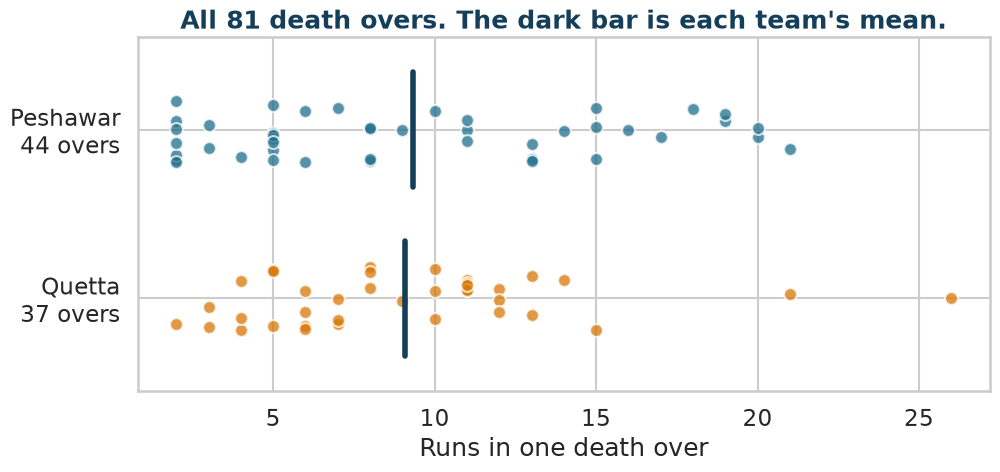

In [10]:
rng = np.random.default_rng(4)
fig, ax = plt.subplots(figsize=(11, 4.6))
for y, team in enumerate([P, Q]):
    x = case.loc[case.batting_team == team, "total_runs"]
    ax.scatter(x, y + rng.uniform(-.2, .2, len(x)), s=85, color=COLORS[team], alpha=.75, edgecolor="white")
    ax.plot([x.mean()] * 2, [y - .34, y + .34], color=NAVY, lw=4)
ax.set(yticks=[0, 1], yticklabels=[f"Peshawar\n{len(p)} overs", f"Quetta\n{len(q)} overs"],
       xlabel="Runs in one death over", ylim=(1.55, -.55),
       title="All 81 death overs. The dark bar is each team's mean.")
save(fig, "dots_by_team.png")
plt.show()

In [11]:
LOW, HIGH = 4, 15
edges = pd.DataFrame({
    "overs": case.groupby("batting_team").size(),
    f"{LOW} runs or fewer": case.groupby("batting_team").total_runs.apply(lambda s: int((s <= LOW).sum())),
    f"{HIGH} runs or more": case.groupby("batting_team").total_runs.apply(lambda s: int((s >= HIGH).sum())),
})
RESULTS.update(low_p=int(edges.loc[P].iloc[1]), low_q=int(edges.loc[Q].iloc[1]),
               k_p=int(edges.loc[P].iloc[2]), k_q=int(edges.loc[Q].iloc[2]),
               max_p=int(p.max()), max_q=int(q.max()), min_p=int(p.min()), min_q=int(q.min()))
edges

,overs,4 runs or fewer,15 runs or more
batting_team,,,
Peshawar Zalmi,44,10,11
Quetta Gladiators,37,6,3


**Question forced by Act 1:** the means agree and the dots do not. If the mean is not what differs, what exactly does?

# Act 2 — What exactly differs?

A distribution is every value and how often it occurs. A summary answers one question about it. We first look at the whole shape, then ask which summary answers which question.

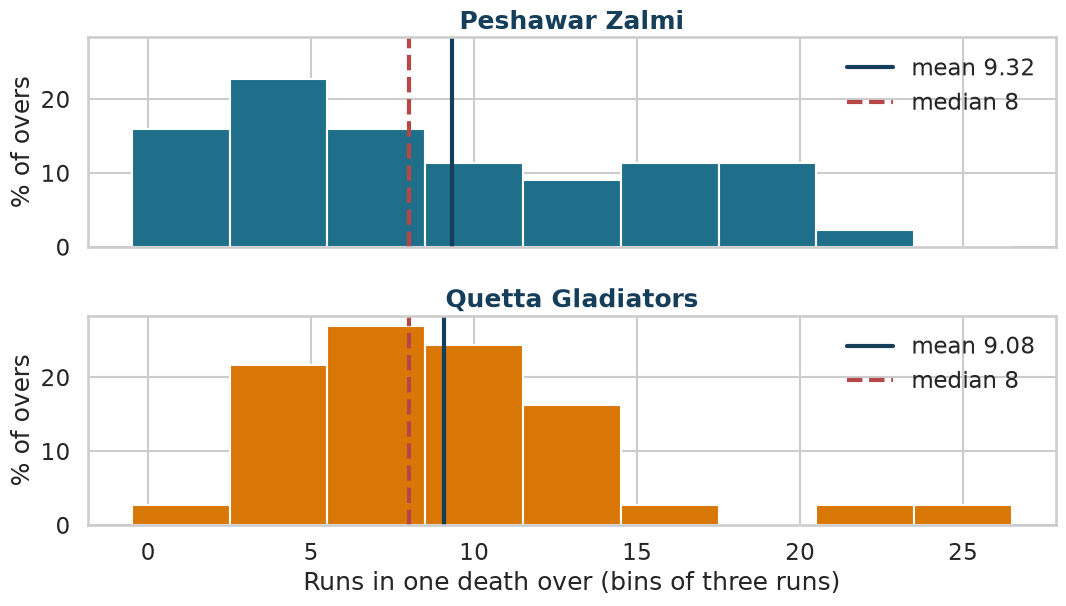

In [12]:
bins = np.arange(-.5, 28.5, 3)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, sharey=True)
for ax, team, x in zip(axes, [P, Q], [p, q]):
    ax.hist(x, bins=bins, weights=np.ones(len(x)) / len(x) * 100, color=COLORS[team], edgecolor="white")
    ax.axvline(x.mean(), color=NAVY, lw=3, label=f"mean {x.mean():.2f}")
    ax.axvline(np.median(x), color=RED, lw=3, ls="--", label=f"median {np.median(x):.0f}")
    ax.set(ylabel="% of overs", title=team)
    ax.legend(frameon=False)
axes[1].set_xlabel("Runs in one death over (bins of three runs)")
fig.tight_layout()
save(fig, "hist_by_team.png")
plt.show()

**Histogram caveat.** The picture changes with bin width. The empirical cumulative distribution function (ECDF) has no bins:

$$\widehat F_n(x)=\frac1n\sum_{i=1}^n \mathbf 1(x_i\le x)$$

It answers: *what fraction of overs scored at most x runs?*

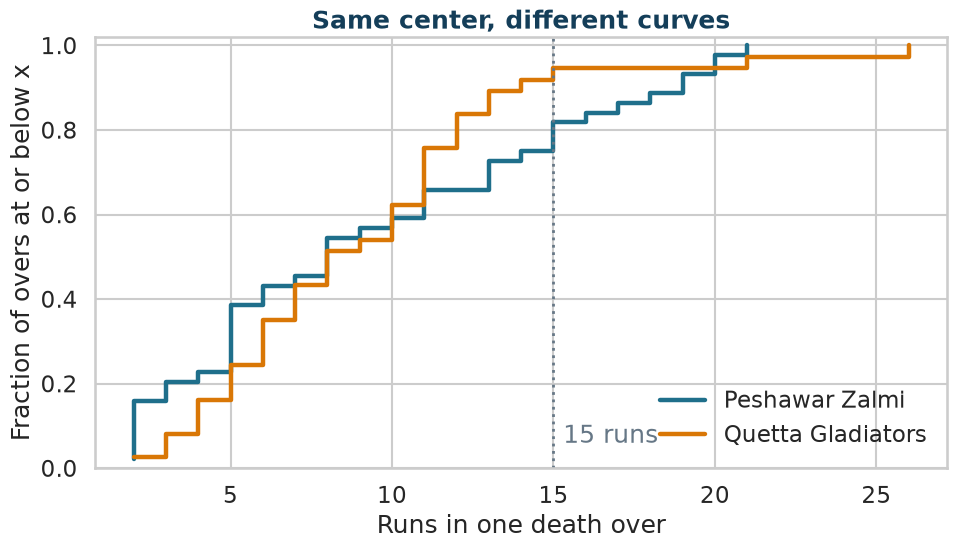

In [13]:
fig, ax = plt.subplots(figsize=(11, 5.6))
for team, x in [(P, p), (Q, q)]:
    xs = np.sort(x)
    ax.step(xs, np.arange(1, len(xs) + 1) / len(xs), where="post", lw=3.2, color=COLORS[team], label=team)
ax.axvline(15, color=GRAY, ls=":", lw=2)
ax.text(15.3, .06, "15 runs", color=GRAY)
ax.set(xlabel="Runs in one death over", ylabel="Fraction of overs at or below x", ylim=(0, 1.02),
       title="Same center, different curves")
ax.legend(frameon=False, loc="lower right")
save(fig, "ecdf.png")
plt.show()

**Read the ECDF.** Where the Peshawar curve is *higher*, more of its overs are at or below that value. Peshawar starts higher (more very low overs) and finishes lower (more very high overs). The curves cross. That crossing is the picture of "same average, different shape."

---

## Which summary answers which question?

| Question | Summary |
|---|---|
| What total should I expect over many overs? | mean |
| What does a typical over look like? | median |
| How bad or good can it get? | quantiles (10th, 90th) |
| How often does an over exceed a decision line? | tail rate $P(X\ge c)$ |

The mean, median and a quantile are also the answers to three different **loss functions**. Machine-learning students already know two of them: squared error and absolute error.

**Predict:** for Peshawar's 44 overs, which single number *c* minimizes (a) mean squared error, (b) mean absolute error, (c) the pinball loss for the 90th percentile? Compare your guess with the sample mean, median and 90th percentile.

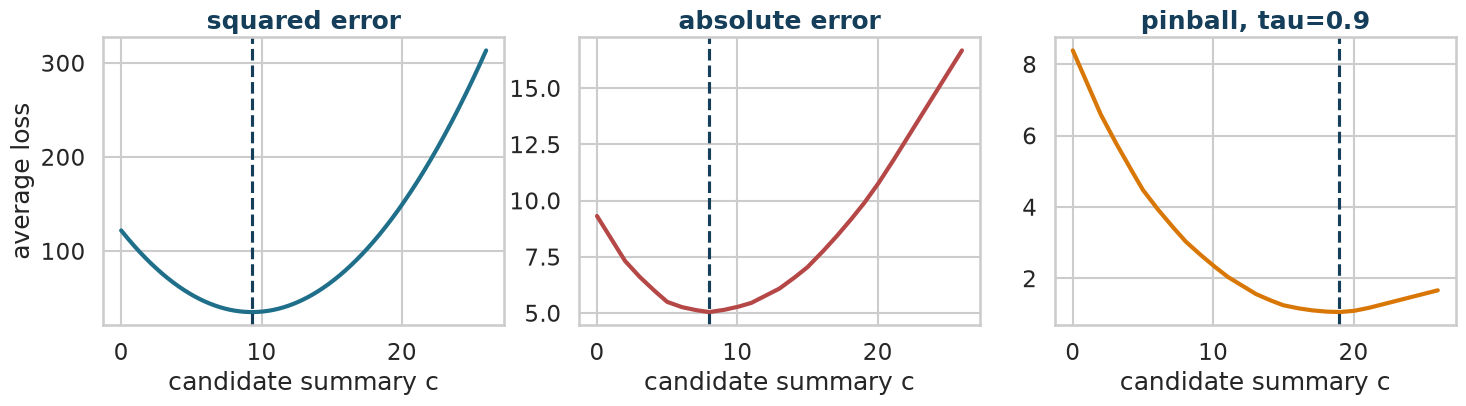

,minimizer of the loss,matching summary
squared error,9.300,9.318
absolute error,8.000,8.000
"pinball, tau=0.9",19.000,19.000


In [14]:
grid = np.linspace(0, 26, 521)
u = p[:, None] - grid
mse = (u ** 2).mean(0)
mae = np.abs(u).mean(0)
tau = .9
pinball = np.maximum(tau * u, (tau - 1) * u).mean(0)
best = {"squared error": grid[mse.argmin()], "absolute error": grid[mae.argmin()], "pinball, tau=0.9": grid[pinball.argmin()]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True)
for ax, loss, name, color in zip(axes, [mse, mae, pinball], best, [TEAL, RED, ORANGE]):
    ax.plot(grid, loss, color=color, lw=3)
    ax.axvline(best[name], color=NAVY, ls="--")
    ax.set(title=name, xlabel="candidate summary c")
axes[0].set_ylabel("average loss")
fig.tight_layout()
save(fig, "loss_minimizers.png")
plt.show()

RESULTS.update(argmin_mse=best["squared error"], argmin_mae=best["absolute error"], argmin_pin=best["pinball, tau=0.9"],
               q90_inverted_p=float(np.quantile(p, .9, method="inverted_cdf")))
pd.DataFrame({"minimizer of the loss": list(best.values()),
              "matching summary": [p.mean(), np.median(p), np.quantile(p, .9, method="inverted_cdf")]},
             index=list(best))

**Reading it.** The mean is the best constant for squared error, the median for absolute error, and a quantile for an asymmetric pinball loss. *Choosing a summary is choosing a loss.* In Act 2's question, "what differs?" is really "what do we care about losing?"

---

## Skew and pooled distributions

Skew (a long right tail) pulls the mean above the median. Pooling can also hide structure. The next cell uses all 13,336 complete PSL overs.

In [15]:
def describe(x):
    x = pd.Series(x)
    return pd.Series({"n": len(x), "mean": x.mean(), "median": x.median(), "sd": x.std(ddof=1),
                      "skew": stats.skew(x), "q10": x.quantile(.10), "q25": x.quantile(.25),
                      "q75": x.quantile(.75), "q90": x.quantile(.90), "max": x.max(),
                      "share_15plus": (x >= 15).mean()})

summary = pd.DataFrame({"Peshawar": describe(p), "Quetta": describe(q)})
for key in ["mean", "median", "sd", "skew", "q10", "q25", "q75", "q90"]:
    RESULTS[f"{key}_p"], RESULTS[f"{key}_q"] = summary.loc[key, "Peshawar"], summary.loc[key, "Quetta"]
summary

,Peshawar,Quetta
n,44.000,37.000
mean,9.318,9.081
median,8.000,8.000
sd,5.999,4.918
skew,0.437,1.313
q10,2.000,4.000
q25,5.000,6.000
q75,14.250,11.000
q90,18.700,13.400
max,21.000,26.000


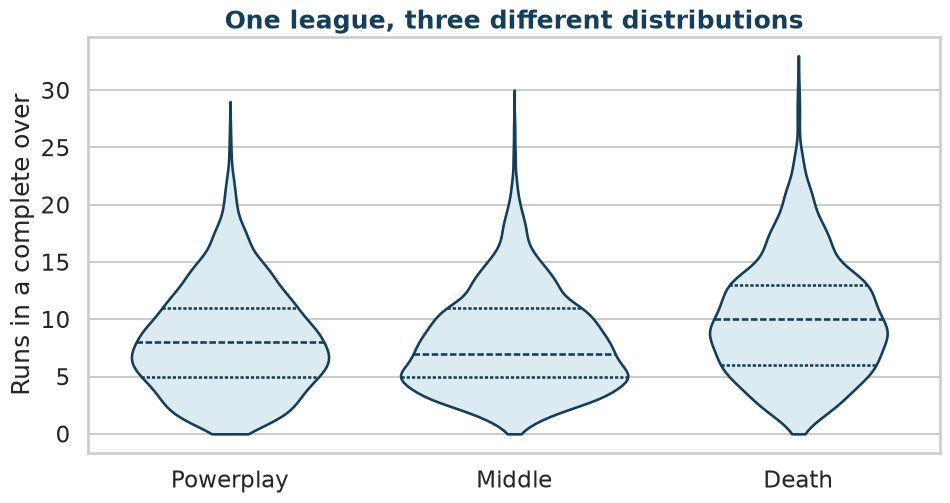

,overs,mean,median,sd,skew
phase,,,,,
Powerplay,4272,8.230,8.000,4.677,0.618
Middle,6278,7.990,7.000,4.334,0.825
Death,2786,10.108,10.000,5.135,0.624


In [16]:
complete = overs[overs.complete_over]
order = ["Powerplay", "Middle", "Death"]
fig, ax = plt.subplots(figsize=(11, 5.4))
sns.violinplot(data=complete, x="phase", y="total_runs", order=order, inner="quart", cut=0,
               color="#d9edf4", linecolor=NAVY, ax=ax)
ax.set(xlabel="", ylabel="Runs in a complete over", title="One league, three different distributions")
save(fig, "phase_distributions.png")
plt.show()

by_phase = complete.groupby("phase").total_runs.agg(
    overs="size", mean="mean", median="median", sd="std", skew=lambda s: stats.skew(s)).loc[order]
for ph, row in by_phase.iterrows():
    RESULTS[f"phase_{ph.lower()}_mean"] = row["mean"]
    RESULTS[f"phase_{ph.lower()}_sd"] = row["sd"]
    RESULTS[f"phase_{ph.lower()}_skew"] = row["skew"]
by_phase

**Scale changes the question.** A log scale compresses large overs. It is a legitimate choice, but the result answers a *ratio* question, not a runs question.

In [17]:
def back_transformed_log_mean(x):
    return np.expm1(np.log1p(x).mean())

scale = pd.DataFrame({
    "raw mean": [p.mean(), q.mean()],
    "median": [np.median(p), np.median(q)],
    "back-transformed log mean": [back_transformed_log_mean(p), back_transformed_log_mean(q)],
}, index=["Peshawar", "Quetta"])
scale.loc["Peshawar minus Quetta"] = scale.loc["Peshawar"] - scale.loc["Quetta"]
RESULTS.update(logmean_p=scale.loc["Peshawar", "back-transformed log mean"],
               logmean_q=scale.loc["Quetta", "back-transformed log mean"],
               logmean_diff=scale.loc["Peshawar minus Quetta", "back-transformed log mean"])
scale

,raw mean,median,back-transformed log mean
Peshawar,9.318,8.000,7.529
Quetta,9.081,8.000,8.037
Peshawar minus Quetta,0.237,0.000,-0.508


## Quantiles and tail rates

A quantile profile compares the two distributions at several points instead of one.

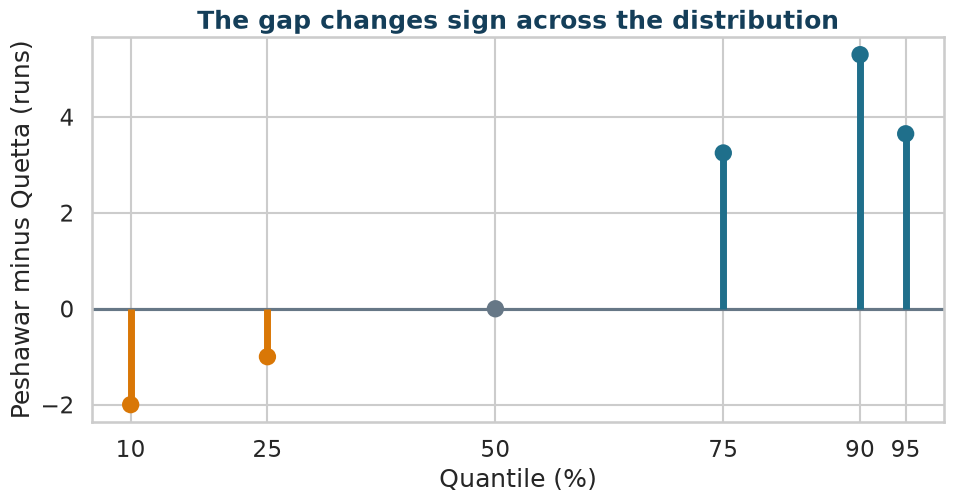

,quantile,Peshawar,Quetta,difference
0,0.100,2.000,4.000,-2.000
1,0.250,5.000,6.000,-1.000
2,0.500,8.000,8.000,0.000
3,0.750,14.250,11.000,3.250
4,0.900,18.700,13.400,5.300
5,0.950,19.850,16.200,3.650


In [18]:
taus = np.array([.10, .25, .50, .75, .90, .95])
qp, qq = np.quantile(p, taus), np.quantile(q, taus)
quantiles = pd.DataFrame({"quantile": taus, "Peshawar": qp, "Quetta": qq, "difference": qp - qq})
for t, d in zip(taus, qp - qq):
    RESULTS[f"qdiff_{int(t * 100)}"] = d

fig, ax = plt.subplots(figsize=(11, 5))
diff = qp - qq
cols = [ORANGE if d < 0 else TEAL if d > 0 else GRAY for d in diff]
ax.axhline(0, color=GRAY)
ax.vlines(taus * 100, 0, diff, color=cols, lw=5)
ax.scatter(taus * 100, diff, color=cols, s=120, zorder=3)
ax.set(xlabel="Quantile (%)", ylabel="Peshawar minus Quetta (runs)", xticks=taus * 100,
       title="The gap changes sign across the distribution")
save(fig, "quantile_differences.png")
plt.show()
quantiles

A **tail rate** answers a decision question: *how often does an over reach 15 runs or more?* The definition of "tail" is a choice, so check how the gap depends on it.

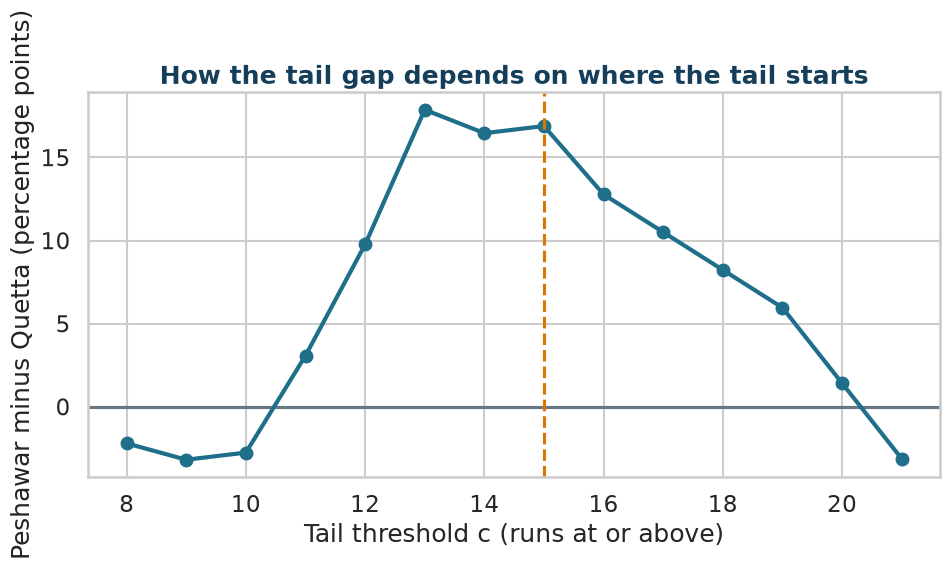

,threshold c,Peshawar rate %,Quetta rate %,gap pp
0,8,54.545,56.757,-2.211
1,9,45.455,48.649,-3.194
2,10,43.182,45.946,-2.764
3,11,40.909,37.838,3.071
4,12,34.091,24.324,9.767
5,13,34.091,16.216,17.875
6,14,27.273,10.811,16.462
7,15,25.000,8.108,16.892
8,16,18.182,5.405,12.776
9,17,15.909,5.405,10.504


In [19]:
thresholds = np.arange(8, 22)
gap = np.array([((p >= c).mean() - (q >= c).mean()) * 100 for c in thresholds])
RESULTS.update(tail_p_pct=(p >= 15).mean() * 100, tail_q_pct=(q >= 15).mean() * 100,
               tail_diff_pp=((p >= 15).mean() - (q >= 15).mean()) * 100)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, color=GRAY)
ax.plot(thresholds, gap, marker="o", lw=3, color=TEAL)
ax.axvline(15, color=ORANGE, ls="--")
ax.set(xlabel="Tail threshold c (runs at or above)", ylabel="Peshawar minus Quetta (percentage points)",
       title="How the tail gap depends on where the tail starts")
save(fig, "tail_gap.png")
plt.show()
pd.DataFrame({"threshold c": thresholds, "Peshawar rate %": [(p >= c).mean() * 100 for c in thresholds],
              "Quetta rate %": [(q >= c).mean() * 100 for c in thresholds], "gap pp": gap})

**Question forced by Act 2:** we now have many differences (mean, median, quantiles, tail rate). Which one is the effect, and is there a single number for "does a random Peshawar over beat a random Quetta over"?

---

## An effect-size family

| Question | Estimand |
|---|---|
| Expected difference in runs | mean difference |
| Typical over | median difference |
| High-scoring capacity | 90th-percentile difference |
| Frequency above 15 | tail-rate difference |
| Does a random Peshawar over beat a random Quetta over? | probability of superiority $\theta=P(X_P>X_Q)+\tfrac12P(X_P=X_Q)$ |

The probability of superiority is the **area under the ROC curve** you will meet in Week 10: if you tried to guess the team from the over's run count, $\theta$ is the AUC. It equals the Mann–Whitney U statistic divided by $n_Pn_Q$.

**Predict:** the tail gap is 17 percentage points. Will $\theta$ be far above 0.5?

In [20]:
pairwise = p[:, None] - q[None, :]
theta = (pairwise > 0).mean() + .5 * (pairwise == 0).mean()
delta = np.sign(pairwise).mean()
auc_via_mannwhitney = stats.mannwhitneyu(p, q).statistic / (len(p) * len(q))
assert np.isclose(theta, auc_via_mannwhitney)     # theta really is the AUC

RESULTS.update(mean_diff=p.mean() - q.mean(), median_diff=np.median(p) - np.median(q),
               q90_diff=np.quantile(p, .9) - np.quantile(q, .9), theta=theta, delta=delta)
pd.Series({
    "mean difference (runs)": p.mean() - q.mean(),
    "median difference (runs)": np.median(p) - np.median(q),
    "90th-percentile difference (runs)": np.quantile(p, .9) - np.quantile(q, .9),
    "tail-rate difference (15+, pp)": ((p >= 15).mean() - (q >= 15).mean()) * 100,
    "probability of superiority = AUC": theta,
    "Cliff's delta = 2*theta - 1": delta,
}, name="Peshawar vs Quetta")

mean difference (runs)               0.237
median difference (runs)             0.000
90th-percentile difference (runs)    5.300
tail-rate difference (15+, pp)      16.892
probability of superiority = AUC     0.493
Cliff's delta = 2*theta - 1         -0.015
Name: Peshawar vs Quetta, dtype: float64

**Reading θ ≈ 0.49.** A classifier that sees only the run count cannot separate the two teams' overs. The tail gap is real in this archive, but it lives in a small part of the distribution, not in a global ordering of overs.

**A quantile–quantile plot** compares two distributions point by point. It is the same tool used to check whether generated data match real data in a generative model: matching the mean is easy, matching the tails is the test.

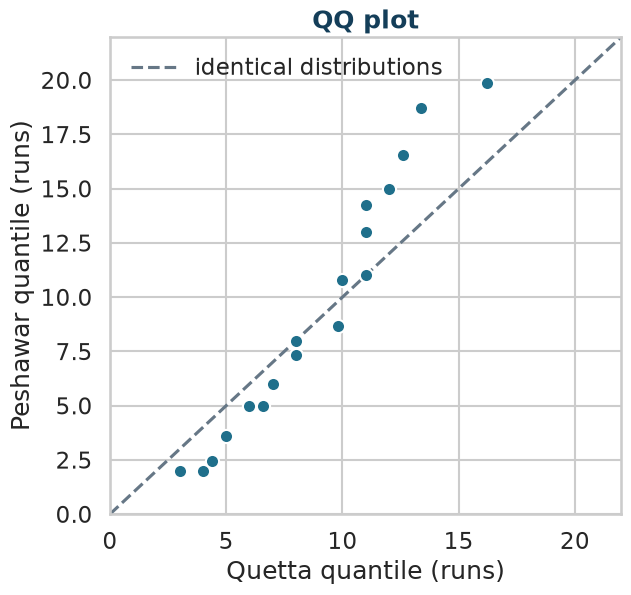

In [21]:
probs = np.linspace(.05, .95, 19)
fig, ax = plt.subplots(figsize=(6.6, 6.2))
ax.plot([0, 22], [0, 22], color=GRAY, ls="--", label="identical distributions")
ax.scatter(np.quantile(q, probs), np.quantile(p, probs), s=90, color=TEAL, edgecolor="white", zorder=3)
ax.set(xlabel="Quetta quantile (runs)", ylabel="Peshawar quantile (runs)", title="QQ plot",
       xlim=(0, 22), ylim=(0, 22))
ax.legend(frameon=False)
save(fig, "qq_plot.png")
plt.show()

**Read the QQ plot.** Points below the dashed line: Peshawar is lower at that quantile. Points above: Peshawar is higher. Same center, but the lower half sits below the line and the upper tail rises above it.

**Claim v2 (so far):** *Peshawar and Quetta have the same average and the same median, but in this archive Peshawar has more very weak overs and more very strong ones.* Each estimate above treated the 81 overs as 81 independent pieces of evidence.

**Question forced by Act 2:** are they?

# Act 3 — How many observations do we really have?

Count the matches behind the 81 rows.

In [22]:
counts = case.groupby(["match_id", "batting_team"]).size().unstack(fill_value=0)
n_matches = len(counts)
both = int(((counts[P] > 0) & (counts[Q] > 0)).sum())
clusters = int((counts > 0).sum().sum())
assert (len(case), n_matches, clusters, both) == (81, 17, 20, 3)
RESULTS.update(matches=n_matches, clusters=clusters, shared_matches=both,
               matches_p=int((counts[P] > 0).sum()), matches_q=int((counts[Q] > 0).sum()),
               max_per_cluster=int(counts.to_numpy().max()))
pd.Series({"over rows": len(case), "team-match clusters": clusters, "distinct matches": n_matches,
           "matches in which both teams appear": both})

over rows                             81
team-match clusters                   20
distinct matches                      17
matches in which both teams appear     3
dtype: int64

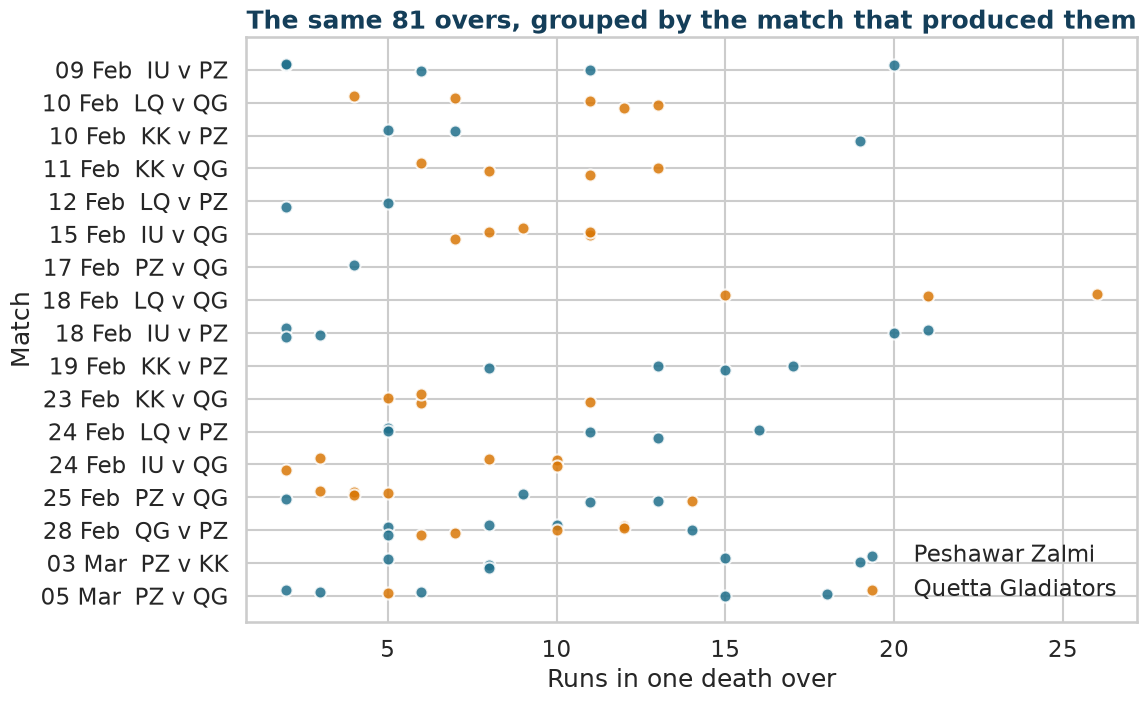

In [23]:
labels = dict(zip(s17.match_id, s17.label))
case["match_label"] = case.match_id.map(labels)
rng = np.random.default_rng(11)
fig, ax = plt.subplots(figsize=(11.5, 7.6))
ypos = {labels[m]: i for i, m in enumerate(sorted(case.match_id.unique(), key=lambda m: (s17.set_index("match_id").match_date[m], m)))}
for team in [P, Q]:
    d = case[case.batting_team == team]
    ax.scatter(d.total_runs, d.match_label.map(ypos) + rng.uniform(-.2, .2, len(d)), s=75,
               color=COLORS[team], alpha=.85, edgecolor="white", label=team)
ax.set_yticks(list(ypos.values()), list(ypos.keys()))
ax.invert_yaxis()
ax.set(xlabel="Runs in one death over", ylabel="Match", title="The same 81 overs, grouped by the match that produced them")
ax.legend(frameon=False, loc="lower right")
save(fig, "dots_by_match.png")
plt.show()

**Read the plot.** 81 rows come from **17 matches**. Fourteen matches contribute overs from one team; three (rows with both colours) contribute overs from both. Overs inside a match share a pitch, weather, a target, and the wickets already lost. Two rows from one match are not two independent draws.

**A bridge you already know:** this is *group leakage*. A random train/test split lets rows from one group sit on both sides and inflates your score; `GroupKFold` keeps groups whole. The statistical version: treating rows of one group as independent inflates your confidence. This is called **pseudoreplication**.

**Can the data show the dependence?** Test whether overs from the same match resemble each other more than chance, by shuffling match labels.

In [24]:
y = case.total_runs - case.groupby("batting_team").total_runs.transform("mean")   # remove the team level
codes = pd.factorize(case.match_id)[0]

def share_explained_by_match(values, groups):
    totals, sizes = np.bincount(groups, values), np.bincount(groups)
    return (totals ** 2 / sizes).sum() / (values ** 2).sum()

observed = share_explained_by_match(y.to_numpy(), codes)
rng = np.random.default_rng(7)
null = np.array([share_explained_by_match(y.to_numpy(), rng.permutation(codes)) for _ in range(5000)])
RESULTS.update(eta=observed, eta_null=null.mean(), eta_p=(null >= observed).mean())
pd.Series({"share of variation explained by match": observed,
           "expected if labels were random": null.mean(),
           "permutation p-value": (null >= observed).mean()})

share of variation explained by match   0.281
expected if labels were random          0.199
permutation p-value                     0.099
dtype: float64

**Reading it.** Match explains a little more than chance would, but 81 rows cannot prove it. **Absence of proof is not proof of independence.** The reason to respect matches is how the data were produced, not a significance test on 81 rows.

---

## Which observations get equal weight?

Aggregating overs into a team mean gives every over the same weight, so a match that contributed five overs counts five times as much as a match that contributed one.

$$\bar x_{\text{over}}=\frac{\sum_m n_m\bar x_m}{\sum_m n_m}\qquad
\bar x_{\text{match}}=\frac1M\sum_m\bar x_m$$

The first describes a *randomly chosen over*; the second describes a *randomly chosen match*. Both are legitimate targets. They are different questions.

**Predict:** will the mean difference stay at about +0.24 runs when every match, rather than every over, gets equal weight?

In [25]:
cluster = (case.groupby(["batting_team", "match_id"]).total_runs
           .agg(n_overs="size", mean_runs="mean", tail_rate=lambda s: (s >= 15).mean()).reset_index())

def estimands(team):
    g = cluster[cluster.batting_team == team]
    return {"overs": int(g.n_overs.sum()), "matches": len(g),
            "mean, equal overs": np.average(g.mean_runs, weights=g.n_overs),
            "mean, equal matches": g.mean_runs.mean(),
            "15+ rate %, equal overs": np.average(g.tail_rate, weights=g.n_overs) * 100,
            "15+ rate %, equal matches": g.tail_rate.mean() * 100}

est = pd.DataFrame({"Peshawar": estimands(P), "Quetta": estimands(Q)})
est["Peshawar minus Quetta"] = est.Peshawar - est.Quetta
d = est["Peshawar minus Quetta"]
RESULTS.update(
    mean_p_match=est.loc["mean, equal matches", "Peshawar"], mean_q_match=est.loc["mean, equal matches", "Quetta"],
    mean_diff_match=d["mean, equal matches"], mean_diff_over=d["mean, equal overs"],
    tail_p_match_pct=est.loc["15+ rate %, equal matches", "Peshawar"], tail_q_match_pct=est.loc["15+ rate %, equal matches", "Quetta"],
    tail_diff_match_pp=d["15+ rate %, equal matches"], tail_diff_over_pp=d["15+ rate %, equal overs"])
assert np.isclose(d["mean, equal overs"], p.mean() - q.mean())
est

,Peshawar,Quetta,Peshawar minus Quetta
overs,44.000,37.000,7.000
matches,11.000,9.000,2.000
"mean, equal overs",9.318,9.081,0.237
"mean, equal matches",8.712,9.196,-0.484
"15+ rate %, equal overs",25.000,8.108,16.892
"15+ rate %, equal matches",22.121,11.111,11.010


**The mean difference changes sign**, from about +0.24 to about −0.48. Neither is "the correct one". Both are small next to the spread of overs. The lesson is that an aggregate hides a *weighting rule*, and the question you care about picks the rule.

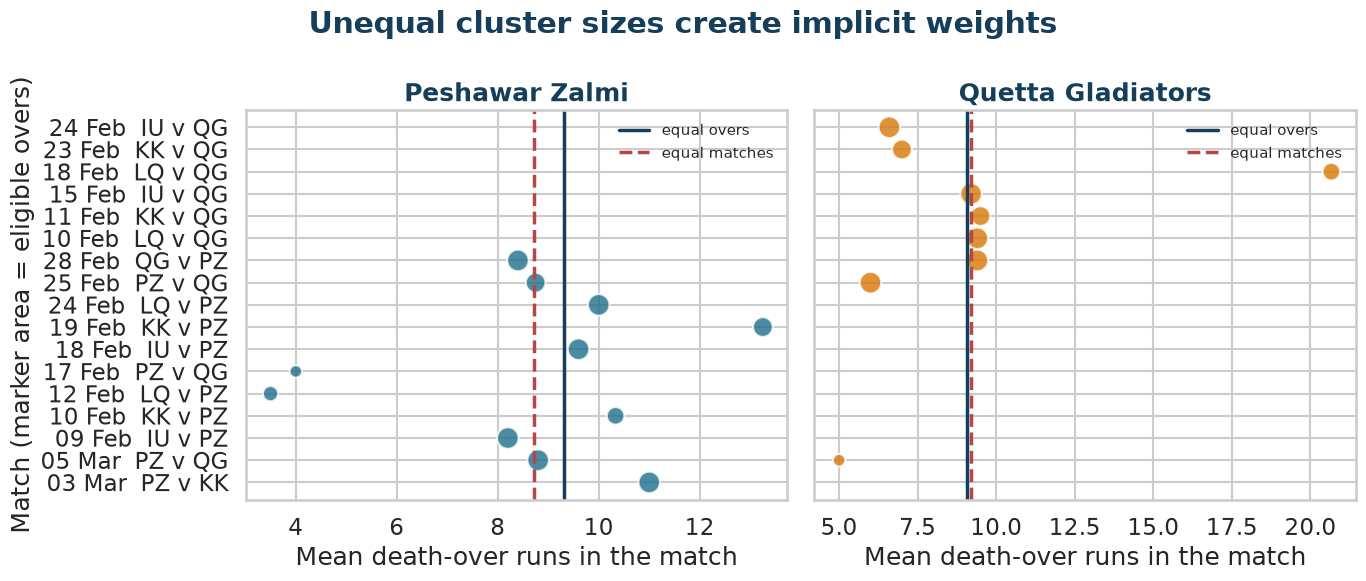

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, team in zip(axes, [P, Q]):
    g = cluster[cluster.batting_team == team].copy()
    g["label"] = g.match_id.map(labels)
    g = g.sort_values("label")
    ax.scatter(g.mean_runs, g.label, s=40 + g.n_overs * 40, color=COLORS[team], alpha=.8, edgecolor="white")
    ax.axvline(est.loc["mean, equal overs", "Peshawar" if team == P else "Quetta"], color=NAVY, lw=2.5, label="equal overs")
    ax.axvline(est.loc["mean, equal matches", "Peshawar" if team == P else "Quetta"], color=RED, lw=2.5, ls="--", label="equal matches")
    ax.set(title=team, xlabel="Mean death-over runs in the match")
    ax.legend(frameon=False, fontsize=11)
axes[0].set_ylabel("Match (marker area = eligible overs)")
fig.suptitle("Unequal cluster sizes create implicit weights", color=NAVY, fontweight="bold")
fig.tight_layout()
save(fig, "match_weighting.png")
plt.show()

**Claim v3:** *In this archive Peshawar has the higher rate of 15+ overs. The mean difference is not stable in sign once weighting is stated. Only 17 matches produced the data.*

**Question forced by Act 3:** if the real unit is the match, how sure can we be about the tail gap?

# Act 4 — How sure are we?

An **interval** is only as honest as the repetition it imitates. The **bootstrap** repeats the study by redrawing from the data we have.

- **IID bootstrap:** draw overs, treating every over as an independent unit.
- **Match-cluster bootstrap:** draw whole *matches*. A drawn match brings all of its overs, for both teams, so shared-match dependence stays in the resample.

**Predict:** which interval for the tail gap will be wider, and by how much?

In [27]:
B = 20_000
rng = np.random.default_rng(854)

# IID bootstrap: the over is the unit.
ip = rng.choice(p, (B, len(p)))
iq = rng.choice(q, (B, len(q)))
iid_mean = ip.mean(1) - iq.mean(1)
iid_tail = (ip >= 15).mean(1) - (iq >= 15).mean(1)

# Match-cluster bootstrap: the match is the unit; a drawn match brings both teams' overs.
match_ids = sorted(case.match_id.unique())
def per_match(team):
    g = case[case.batting_team == team].groupby("match_id").total_runs
    t = g.agg(n="size", runs="sum", hits=lambda s: (s >= 15).sum())
    return t.reindex(match_ids, fill_value=0).to_numpy()

TP, TQ = per_match(P), per_match(Q)
draw = rng.integers(0, len(match_ids), (B, len(match_ids)))
def rates(T):
    n = T[draw, 0].sum(1)
    return T[draw, 1].sum(1) / n, T[draw, 2].sum(1) / n
(mp, tp), (mq, tq) = rates(TP), rates(TQ)
cl_mean, cl_tail = mp - mq, tp - tq
assert np.isfinite(cl_mean).all()   # no resample left a team without overs

def interval(x, scale=1):
    lo, med, hi = np.quantile(x, [.025, .5, .975]) * scale
    return pd.Series({"lower 2.5%": lo, "median": med, "upper 97.5%": hi, "width": hi - lo})

intervals = pd.DataFrame({
    "IID, mean (runs)": interval(iid_mean), "cluster, mean (runs)": interval(cl_mean),
    "IID, 15+ gap (pp)": interval(iid_tail, 100), "cluster, 15+ gap (pp)": interval(cl_tail, 100)}).T
for name, key in [("IID, mean (runs)", "iid_mean"), ("cluster, mean (runs)", "cl_mean"),
                  ("IID, 15+ gap (pp)", "iid_tail"), ("cluster, 15+ gap (pp)", "cl_tail")]:
    RESULTS[f"{key}_lo"], RESULTS[f"{key}_hi"] = intervals.loc[name, "lower 2.5%"], intervals.loc[name, "upper 97.5%"]
    RESULTS[f"{key}_width"] = intervals.loc[name, "width"]
RESULTS["boot_draws"] = B
intervals

,lower 2.5%,median,upper 97.5%,width
"IID, mean (runs)",-2.127,0.252,2.569,4.697
"cluster, mean (runs)",-2.745,0.264,2.393,5.137
"IID, 15+ gap (pp)",1.966,16.892,32.801,30.835
"cluster, 15+ gap (pp)",-5.213,17.021,32.653,37.866


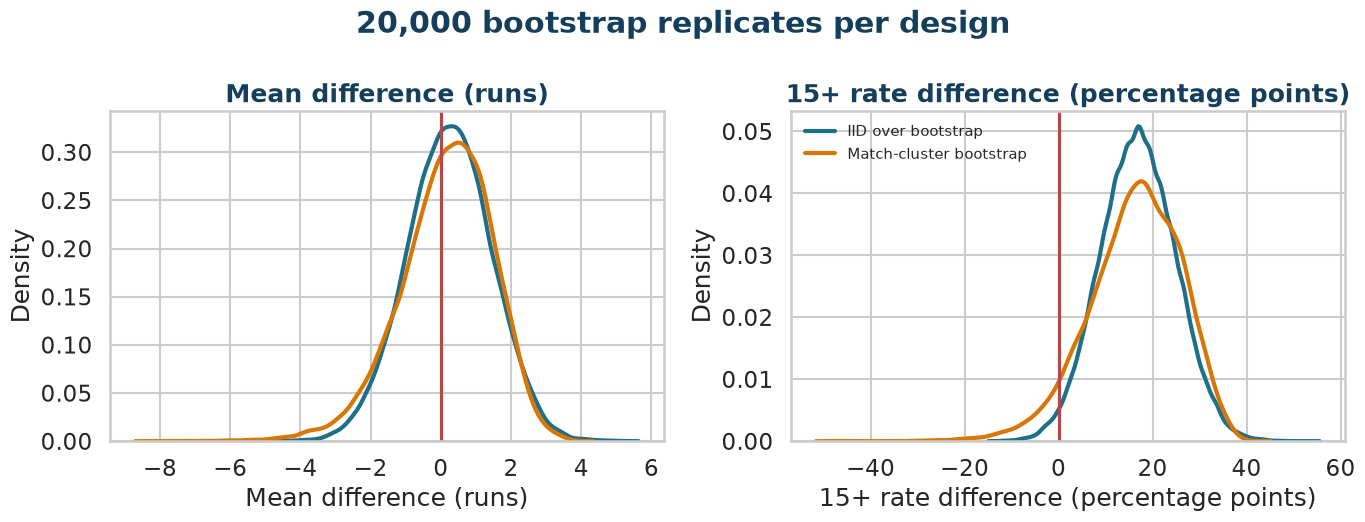

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, (iid, cl, scale, label) in zip(axes, [(iid_mean, cl_mean, 1, "Mean difference (runs)"),
                                               (iid_tail, cl_tail, 100, "15+ rate difference (percentage points)")]):
    sns.kdeplot(iid * scale, ax=ax, color=TEAL, lw=3, label="IID over bootstrap")
    sns.kdeplot(cl * scale, ax=ax, color=ORANGE, lw=3, label="Match-cluster bootstrap")
    ax.axvline(0, color=RED)
    ax.set(xlabel=label, ylabel="Density", title=label)
axes[1].legend(frameon=False, fontsize=11)
fig.suptitle(f"{B:,} bootstrap replicates per design", color=NAVY, fontweight="bold")
fig.tight_layout()
save(fig, "bootstrap_designs.png")
plt.show()

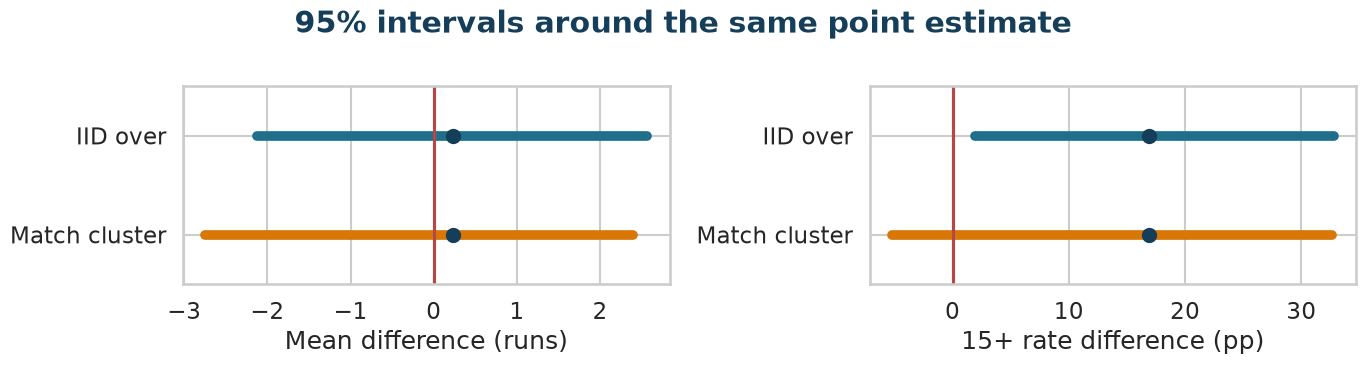

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, keys, est_value, label in [
        (axes[0], ("iid_mean", "cl_mean"), p.mean() - q.mean(), "Mean difference (runs)"),
        (axes[1], ("iid_tail", "cl_tail"), (p >= 15).mean() * 100 - (q >= 15).mean() * 100, "15+ rate difference (pp)")]:
    for y, (key, name, color) in enumerate(zip(keys, ["IID over", "Match cluster"], [TEAL, ORANGE])):
        ax.plot([RESULTS[f"{key}_lo"], RESULTS[f"{key}_hi"]], [y, y], color=color, lw=7, solid_capstyle="round")
        ax.scatter([est_value], [y], color=NAVY, zorder=3, s=90)
    ax.axvline(0, color=RED)
    ax.set(yticks=[0, 1], yticklabels=["IID over", "Match cluster"], xlabel=label, ylim=(1.5, -.5))
fig.suptitle("95% intervals around the same point estimate", color=NAVY, fontweight="bold")
fig.tight_layout()
save(fig, "interval_forest.png")
plt.show()

**Read it.** The point estimate does not move. The interval gets wider when matches are the unit, and its lower end moves from a clearly positive gap to a clearly negative one. The right question is *how wide*, not whether the interval touches zero. An interval containing zero does not show the teams are equal.

**A classical cross-check.** Fisher's exact test on the raw counts (11 of 44 versus 3 of 37 overs at 15+) treats overs as independent. Even that naive test is borderline.

In [30]:
odds, fisher_p = stats.fisher_exact([[RESULTS["k_p"], len(p) - RESULTS["k_p"]], [RESULTS["k_q"], len(q) - RESULTS["k_q"]]])
RESULTS.update(fisher_p=fisher_p, fisher_odds=odds)
pd.Series({"Peshawar 15+ overs": f'{RESULTS["k_p"]} of {len(p)}', "Quetta 15+ overs": f'{RESULTS["k_q"]} of {len(q)}',
           "Fisher exact p (two-sided)": fisher_p})

Peshawar 15+ overs            11 of 44
Quetta 15+ overs               3 of 37
Fisher exact p (two-sided)       0.075
dtype: object

**Even the naive test was borderline**, so the drama is not "significant becomes insignificant". The honest reading is: *the data lean toward a Peshawar tail gap, and the uncertainty is large under either design, larger when the match is the unit.*

## A glance at analyst choices

A tail contrast also depends on where the death phase starts. The full robustness treatment (specification curves, influence, alternative explanations) belongs to Week 14. This one cell shows why it will be needed.

In [31]:
rows = []
for start in [14, 15, 16, 17]:
    f = overs[overs.complete_over & (overs.season_year == 2017) & (overs.over_number >= start) & overs.batting_team.isin([P, Q])]
    fp, fq = f.loc[f.batting_team == P, "total_runs"], f.loc[f.batting_team == Q, "total_runs"]
    rows.append({"death phase starts at over": start, "Peshawar overs": len(fp), "Quetta overs": len(fq),
                 "mean difference (runs)": fp.mean() - fq.mean(),
                 "15+ gap (pp)": ((fp >= 15).mean() - (fq >= 15).mean()) * 100})
    RESULTS[f"ph{start}_mean"], RESULTS[f"ph{start}_tail_pp"] = rows[-1]["mean difference (runs)"], rows[-1]["15+ gap (pp)"]
pd.DataFrame(rows)

,death phase starts at over,Peshawar overs,Quetta overs,mean difference (runs),15+ gap (pp)
0,14,66,55,-0.003,7.273
1,15,55,46,0.407,15.296
2,16,44,37,0.237,16.892
3,17,33,28,0.421,17.100


**Tail gap: positive under every start. Mean gap: changes size and nearly disappears.** A defensible study reports its analyst choices instead of choosing the most flattering one.

---

# Act 5 — What can we defend?

| Rung | Statement | Supported here? |
|---|---|---|
| Archive description | In these recorded overs, Peshawar reached 15+ more often | yes, exact |
| Distributional detail | Same mean and median, more weak and more strong overs | yes, exact |
| Process inference | Peshawar would repeat a higher 15+ rate in new matches | weak; the interval is wide |
| Generalization | The pattern holds across seasons | not tested |
| Causal explanation | Peshawar's strategy causes explosive overs | not supported; no design isolates it |

**Language stops where the design stops.**

In [32]:
with open(DATA / "results.json", "w") as handle:
    json.dump({k: float(v) if not isinstance(v, (int, str)) else v for k, v in RESULTS.items()}, handle, indent=2)
len(RESULTS)

118